# Robustness Study: Data Collection

## Loading Libraries & Preparations

In [1]:
import os
import numpy as np
import pandas as pd
import json
import openai
import anthropic
from tqdm import tqdm
import yfinance as yf
import matplotlib as mpl
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import string

tqdm.pandas()

In [ ]:
openai.api_key = os.getenv('OPENAI_API_KEY')    
openai_client = openai.OpenAI()

anthropic_client = anthropic.Anthropic()

In [ ]:
gpt_4o = 'gpt-4o-2024-08-06'
claude_sonnet = 'claude-3-5-sonnet-20241022'

In [ ]:
def get_gpt_response(prompt, model=gpt_4o):
    try:
        res = openai_client.chat.completions.create(
            model=model,
            messages = [{"role": "user", "content": prompt}],
            seed=1337,
            response_format={"type": "json_object" },
        ) 
        return res.choices[0].message.content
    except Exception as e:
        print(f'error GPT:{e}')
        return get_gpt_response(model, prompt)

def get_anthropic_response(prompt, model=claude_sonnet):
    try:
        res = anthropic_client.messages.create(
            model=model,
            messages=[{"role": "user", "content": prompt}, {"role": "assistant","content": "Here is the JSON requested:\n{"}],
            max_tokens = 1024
        )
        text = res.content[0].text
        return "{" + text[:text.rfind("}") + 1]
    except Exception as e:
        print(f'error Anthropic:{e}')
        return get_anthropic_response(model, prompt)

In [ ]:
df = pd.DataFrame(columns=['age', 'risk_taking', 'iteration', 'prompt'])

iterations = 5
ages = [15, 30, 50]
risk_taking = ['low', 'medium', 'high']

for age in ages:
    prompt_skeletons = {
        "low" : '''Hi, I'm a {}-year-old looking to invest $10,000. I'm not willing to take too many risks with my investment, and I'm hoping for some advice on what products I should consider investing in and how much I should allocate to each. Can you provide me with some recommendations? Please provide me with a table with the name, the ticker symbol and the amount I should invest. **Make sure the total of all listed investments adds up to $10,000**. Respond in the following **JSON** structure: {{"investments": [{{"name":"Microsoft", "ticker": "MSFT", "amount": 1000}}]}}'''.format(age),
        "medium": '''Hi, I'm a {}-year-old looking to invest $10,000. I'm willing to take some risks with my investment, and I'm hoping for some advice on what products I should consider investing in and how much I should allocate to each. Can you provide me with some recommendations? Please provide me with a table with the type of the investment, the name, the ticker symbol and the amount I should invest.  **Make sure the total of all listed investments adds up to $10,000**. Respond in the following **JSON** structure: {{"investments": [{{"name":"Microsoft", "ticker": "MSFT", "amount": 1000}}]}}'''.format(age),
        "high": '''Hi, I'm a {}-year-old looking to invest $10,000. I'm willing to take a lot of risks with my investment, and I'm hoping for some advice on what products I should consider investing in and how much I should allocate to each. Can you provide me with some recommendations? Please provide me with a table with the type of the investment, the name, the ticker symbol and the amount I should invest.  **Make sure the total of all listed investments adds up to $10,000**. Respond in the following **JSON** structure: {{"investments": [{{"name":"Microsoft", "ticker": "MSFT", "amount": 1000}}]}}'''.format(age)
    }
    
    for risk in risk_taking:
        for i in range(0, iterations):
            df.loc[len(df)] = {
                'age': age,
                'risk_taking': risk,
                'iteration': i,
                'prompt': prompt_skeletons[risk]
            }
            

## Data Collection

In [ ]:
def extract_json(elem):
    try:
        elem_json = json.loads(elem)
        return elem_json['investments']
    except Exception:
        print(f'got error: {Exception} for elem: {elem}')

In [ ]:
df['raw_gpt'] = df['prompt'].progress_apply(get_gpt_response)

In [ ]:
df['gpt'] = df['raw_gpt'].apply(extract_json)

In [ ]:
df['raw_sonnet'] = df['prompt'].progress_apply(get_anthropic_response)

In [ ]:
df['sonnet'] = df['raw_sonnet'].apply(extract_json)

In [ ]:
df.to_csv('./data/responses_raw.csv')

## Data Preparation

In [ ]:
ticker_dict = {}

In [ ]:
df_prep = df.copy()

In [ ]:
df_prep['gpt_sum'] = df['gpt'].apply(lambda x: sum(item['amount'] for item in x if 'amount' in item))
df_prep['sonnet_sum'] = df['sonnet'].apply(lambda x: sum(item['amount'] for item in x if 'amount' in item) )

In [ ]:
df_prep[(df_prep['gpt_sum'] != 10000) | (df_prep['sonnet_sum'] != 10000)] # all are summing up to 10,000

In [ ]:
df_prep = df_prep.drop(columns=['prompt', 'raw_gpt', 'raw_sonnet', 'gpt_sum', 'sonnet_sum'])

In [ ]:
df_long = df_prep.melt(id_vars=['age', 'risk_taking', 'iteration'], 
                  value_vars=['gpt', 'sonnet'], 
                  var_name='ai', 
                  value_name='advice')

In [ ]:
df_expanded = df_long.explode('advice', ignore_index=True)

In [ ]:
df_expanded[['pos_name', 'pos_ticker', 'pos_amount']] = df_expanded['advice'].apply(
    lambda x: pd.Series({
        'pos_name': x.get('name', None),
        'pos_ticker': x.get('ticker', None),
        'pos_amount': x.get('amount', None)
    }) if isinstance(x, dict) else pd.Series({'pos_name': None, 'pos_ticker': None, 'pos_amount': None})
)

df_expanded = df_expanded.drop(columns=['advice'])

In [ ]:
#df_expanded.to_csv('./data/responses_long.csv')

In [ ]:
name_dict = {
    'ETH': 'ETH-USD',
    'BTC': 'BTC-USD',
    'SQ': 'XYZ', # was combined to Block Inc.
    'N/A': None
}

def clean_ticker(ticker):
    if ticker in name_dict:
        return name_dict[ticker]
    return ticker

df_expanded['pos_ticker'] = df_expanded['pos_ticker'].apply(clean_ticker) 

In [ ]:
def get_asset_type(ticker):
    if ticker == None:
        return pd.Series(['Saving', None, None])
        
    if ticker in ticker_dict:
        return ticker_dict[ticker]

    try:
        asset = yf.Ticker(ticker)
        info = asset.info
        assetType = info.get('quoteType')
        country = None
        sector = None
        
        if assetType.lower() == 'equity':
            country = info.get('country')
            sector = info.get('sector')

        ret = pd.Series([assetType, country, sector])
        ticker_dict[ticker]  = ret
            
        return ret
    except Exception as e:
        print(f'Error: {e} for ticker: {ticker}')
        return pd.Series([None, None, None])

df_expanded[['pos_type', 'pos_country', 'pos_sector']] = df_expanded['pos_ticker'].progress_apply(get_asset_type) 

In [ ]:
#df_expanded.to_csv('./data/responses_long.csv')

## Fetching Data

In [2]:
df_expanded = pd.read_csv('./data/responses_long.csv', index_col=0)

In [3]:
etfs = df_expanded[df_expanded['pos_type'] == 'ETF']['pos_ticker'].unique()
funds = df_expanded[df_expanded['pos_type'] == 'MUTUALFUND']['pos_ticker'].unique()
equities = df_expanded[df_expanded['pos_type'] == 'EQUITY']['pos_ticker'].unique()

In [4]:
prev_etf_data = pd.read_csv('../study3/data/refinitiv/complete/etf_data.csv', index_col=0)
prev_fund_data = pd.read_csv('../study3/data/refinitiv/complete/fund_data.csv', index_col=0)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4212942545.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  prev_etf_data = pd.read_csv('../study3/data/refinitiv/complete/etf_data.csv', index_col=0)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4212942545.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  prev_fund_data = pd.read_csv('../study3/data/refinitiv/complete/fund_data.csv', index_col=0)


In [5]:
prev_etfs = prev_etf_data['fund'].unique()
prev_funds = prev_fund_data['fund'].unique()

new_etfs = [item for item in etfs if item not in prev_etfs]
new_funds = [item for item in funds if item not in prev_funds]

print(f'etfs: {new_etfs}')
print(f'funds: {new_funds}')

etfs: ['VGSH', 'SCHP', 'IYR', 'AOR', 'BITO', 'GBTC', 'SHV', 'SOXL', 'TQQQ']
funds: []


In [6]:
resStr_etf = ""
os = ['VGSH', 'SHV', 'TQQQ']
ks = ['SCHP', 'BITO', 'GBTC', 'SOXL']
for etf in new_etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

'VGSH.O;SCHP.K;IYR;AOR;BITO.K;GBTC.K;SHV.O;SOXL.K;TQQQ.O;'

In [7]:
def prepare_refinitiv_dataset(df, columns):
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'economic_sector'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

def prepare_refinitiv_dataset_new(df, columns):
    df = df.iloc[1:].reset_index()
    return prepare_refinitiv_dataset(df, columns)

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector']
etfs_new = pd.read_csv('./data/refinitiv/robustness.csv', index_col=0)
etfs_new = prepare_refinitiv_dataset_new(etfs_new, cols_refinitiv)

cols_refinitiv_tmp = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
prev_etf_data = prepare_refinitiv_dataset(prev_etf_data, cols_refinitiv_tmp)
prev_fund_data = prepare_refinitiv_dataset(prev_fund_data, cols_refinitiv_tmp)

etf_data = pd.concat([prev_etf_data, etfs_new], ignore_index=True)
fund_data = pd.concat([prev_fund_data, etfs_new], ignore_index=True)

In [8]:
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']

def extract_ticker(ticker):
    return ticker.split('.')[0] if '.' in str(ticker) else ticker

def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return extract_ticker(row['ticker']) if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return extract_ticker(row['ticker'])
    
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector
    
def resolve_layer2(df):
    df = df.merge(etf_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    return df

def prepare_data(df):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['sector'] = df.apply(
        lambda row: 'Crypto' if row['asset_type'] == 'CRYPTOCURRENCY' else row['sector'],
        axis=1
    )
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return resolve_layer2(df)

def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df


In [9]:
df_tmp = df_expanded.copy()
df_resolved_cols = ['ai', 'age', 'risk_taking', 'iteration', 'name', 'ticker', 'amount', 'asset_type', 'country', 'sector', 'weight']
rename_dict = {
    'pos_name': 'name',
    'pos_ticker': 'ticker_symbol',
    'pos_amount': 'amount_to_invest',
    'pos_type': 'asset_type',
    'pos_country': 'country',
    'pos_sector': 'sector'
}
df_tmp = df_tmp.rename(columns=rename_dict)

In [10]:
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

df_tmp['weight'] = df_tmp.groupby(['ai', 'age', 'risk_taking', 'iteration'])['amount_to_invest'].transform(get_position_weight)

In [11]:
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [27]:
rename_dict = {
    'risk-taking': 'risk_taking'
}

df_study1 = pd.read_csv('../study1/processed/ageRisk_long.csv', index_col=0)
df_study1_resolved = pd.read_csv('../study1/processed/ageRisk_resolved.csv', index_col=0, low_memory=False)

df_study1 = df_study1.rename(columns=rename_dict)
df_study1['weight'] = df_study1.groupby(['ai', 'age', 'risk_taking', 'iteration'])['amount_to_invest'].transform(get_position_weight)
df_study1 = df_study1.drop(['investment_type'], axis=1)
df_study1['llm'] = 'LLMs Study 1'
df_study1 = df_study1[sorted(df_study1.columns)]
df_tmp['llm'] = df_tmp['ai']
df_tmp = df_tmp[sorted(df_tmp.columns)]
df_full = pd.concat([df_study1, df_tmp], ignore_index=True)

resolved_cols = ['ai', 'age', 'risk_taking', 'iteration', 'ticker', 'asset_type', 'amount', 'weight', 'country', 'sector']
df_study1_resolved = df_study1_resolved.rename(columns=rename_dict)
df_study1_resolved = df_study1_resolved[resolved_cols]
df_study1_resolved['llm'] = 'LLMs Study 1'
df_resolved = prepare_data(df_tmp)
df_resolved = df_resolved[resolved_cols]
df_resolved['llm'] = df_resolved['ai'] 
df_resolved_full = pd.concat([df_study1_resolved, df_resolved], ignore_index=True)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/1000358743.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weight_y'].fillna(1, inplace=True)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/1000358743.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

## Analysis

In [28]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.sans-serif'] = 'Arial'

In [29]:
# Returns a data frame that contains all combinations of two data frames on a certain criterion (elem)
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

# Calculates the weight of a certain characteristic (elem) in a group
def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

# Prepares benchmark data to be handled as a experimental condition
def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['llm'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk_taking'] = 'low'
    df['iteration'] = 0
    return df

# Calculates an ANOVA on a characteristic (column) for the defined groups (group1, group2) and prints the TukeyHSD results
def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
# Calculates a t-test between a sample and a fixed value for a defined grouping
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        d = group_values.mean() - benchmark
        print(f'group: {group_name} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 2)} d: {round(d, 2)}')

def show_ttest_ind(raw, column, groups):
    unique_groups = raw[groups].unique()
    if len(unique_groups) != 2:
        print('Error occured calculating the t-test between the groups.')
        return

    group1, group2 = unique_groups
    data1 = raw[raw[groups] == group1][column].dropna()
    data2 = raw[raw[groups] == group2][column].dropna()
    print(stats.ttest_ind(data1, data2))
    t_stat, p_value = stats.ttest_ind(data1, data2)
    print(f'group1: {group1} and group2: {group2} got t: {round(t_stat,2)}, p_value: {round(p_value,4)}, df: {len(data1) + len(data2) - 2}')
    

# Calculates statistics for a given characteristic (column) within groups
def calc_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    if group2:
        show_anova(raw, column, group1, group2, onlyGroup)
    else:
        if len(raw[group1].unique()) > 2:
            show_anova(raw, column, group1, None, onlyGroup)
        else:
            show_ttest_ind(raw, column, group1)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

# Prints means, standard deviations, and sample sizes for defined groups
def print_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2, onlyGroup)
    
    print(f'means:\n{round(means, 2)}')
    print(f'stds:\n{round(std_devs,2)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    
# Prints mean violinplots of a feature relative to a fixed benchmark value
def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3)  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

# Prints mean barplots of a feature relative to a fixed benchmark value
def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    
# Prints the mean barplots without printing the means, stds, and sample_sizes
def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Prints the mean barplots and prints the means, stds, and sample_sizes
def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Transforms values into percent values
def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['llm','ai', 'age', 'risk_taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')

df_resolved_full['ai'] = df_resolved_full['ai'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_resolved['llm'] = df_resolved['llm'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_resolved['ai'] = df_resolved['ai'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_resolved_full['llm'] = df_resolved_full['llm'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_resolved_full['risk_taking'] = df_resolved_full['risk_taking'].replace({'low': 'averse','medium': 'neutral', 'high': 'seeking'})
df_full['ai'] = df_full['ai'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_full['llm'] = df_full['llm'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_full['risk_taking'] = df_full['risk_taking'].replace({'low': 'averse','medium': 'neutral', 'high': 'seeking'})
df_tmp['ai'] = df_tmp['ai'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_tmp['risk_taking'] = df_tmp['risk_taking'].replace({'low': 'averse','medium': 'neutral', 'high': 'seeking'})
df_study1['ai'] = df_study1['ai'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_study1['risk_taking'] = df_study1['risk_taking'].replace({'low': 'averse','medium': 'neutral', 'high': 'seeking'})

llm_order = ['LLMs Study 1', 'GPT 4o', 'Sonnet 3.5']


In [30]:
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ais = df_tmp['ai'].unique()
    ages = df_tmp['age'].unique()
    risk_taking = df_tmp['risk_taking'].unique()
    iterations = list(range(5))  # 0 to 4
    
    if sep_col:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk_taking', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk_taking', 'iteration', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk_taking', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk_taking', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

In [31]:
def prepare_dataframe_study1(df, col_name, sep_col = None, sep_col_values = None):
    llms = df_study1['llm'].unique()
    ais = df_study1['ai'].unique()
    ages = df_study1['age'].unique()
    risk_taking = df_study1['risk_taking'].unique()
    iterations = list(range(10))  # 0 to 9
    
    if sep_col:
        combinations = list(itertools.product(llms, ais, ages, risk_taking, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['llm', 'ai', 'age', 'risk_taking', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['llm', 'ai', 'age', 'risk_taking', 'iteration', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(llms, ais, ages, risk_taking, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['llm', 'ai', 'age', 'risk_taking', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['llm', 'ai', 'age', 'risk_taking', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

## Geographic cluster risk

In [34]:
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(df_resolved_full)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')
geo_us['llm'] = pd.Categorical(geo_us['llm'], categories=llm_order, ordered=True)
geo_us = geo_us.sort_values(by='llm').reset_index(drop=True)

(9485, 16)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/1002967165.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()


(2703764, 11)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/1002967165.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()


                sum_sq     df         F    PR(>F)
label       184.628739    2.0  1.066557  0.345289
Residual  30813.083208  356.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1       group2    meandiff p-adj   lower  upper  reject
---------------------------------------------------------------
      GPT 4o LLMs Study 1  -1.8604 0.4295 -5.3869 1.6662  False
      GPT 4o   Sonnet 3.5  -0.4531  0.971 -5.0693  4.163  False
LLMs Study 1   Sonnet 3.5   1.4072 0.6159 -2.1193 4.9338  False
---------------------------------------------------------------
group: ('LLMs Study 1',) got t: 60.66 p_value: 0.0 dfs: 268 benchmark: 58.96 d: 35.2
group: ('GPT 4o',) got t: 29.52 p_value: 0.0 dfs: 44 benchmark: 58.96 d: 37.06
group: ('Sonnet 3.5',) got t: 27.9 p_value: 0.0 dfs: 44 benchmark: 58.96 d: 36.61
means:
llm
LLMs Study 1    94.17
GPT 4o          96.03
Sonnet 3.5      95.57
Name: weight, dtype: float64
stds:
llm
LLMs Study 1    9.52
GPT 4o          8.4

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_data in raw.groupby(groups):
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = raw.groupby(groups)[column]


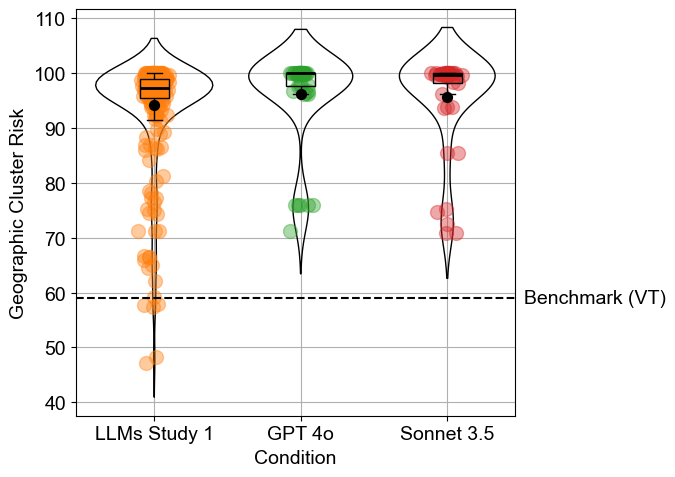

In [35]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'llm',
    'robustness_comb_geoRisk'
)

## Sector cluster risk

In [36]:
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    return df

def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group, observed=False)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group, observed=False)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols, observed=False).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(df_resolved_full)
sec = filtered_df.groupby(group_cols, observed=False).apply(calculate_weight, elem='sector').reset_index()
sec = calculate_concentration(sec, group_cols)
sec['llm'] = pd.Categorical(sec['llm'], categories=llm_order, ordered=True)
sec = sec.sort_values(by='llm').reset_index(drop=True)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/3330558515.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sec_benchmark = benchmark_filtered.groupby(group_cols, observed=False).apply(calculate_weight, elem='sector').reset_index()
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/3330558515.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sec = filtered_df.groupby(gr

             sum_sq     df          F        PR(>F)
label      6.136002    2.0  78.692594  5.002490e-29
Residual  13.879429  356.0        NaN           NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
      GPT 4o LLMs Study 1  -0.2147    0.0 -0.2895 -0.1398   True
      GPT 4o   Sonnet 3.5   0.1489 0.0011  0.0509  0.2469   True
LLMs Study 1   Sonnet 3.5   0.3636    0.0  0.2887  0.4384   True
----------------------------------------------------------------
group: ('LLMs Study 1',) got t: 17.03 p_value: 0.0 dfs: 268 benchmark: 0.15 d: 0.17
group: ('GPT 4o',) got t: 12.52 p_value: 0.0 dfs: 44 benchmark: 0.15 d: 0.39
group: ('Sonnet 3.5',) got t: 10.92 p_value: 0.0 dfs: 44 benchmark: 0.15 d: 0.53
means:
llm
LLMs Study 1    0.32
GPT 4o          0.54
Sonnet 3.5      0.69
Name: concentration, dtype: float64
stds:
llm
LLMs Study 1    0.16
GPT 4o

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_data in raw.groupby(groups):
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = raw.groupby(groups)[column]


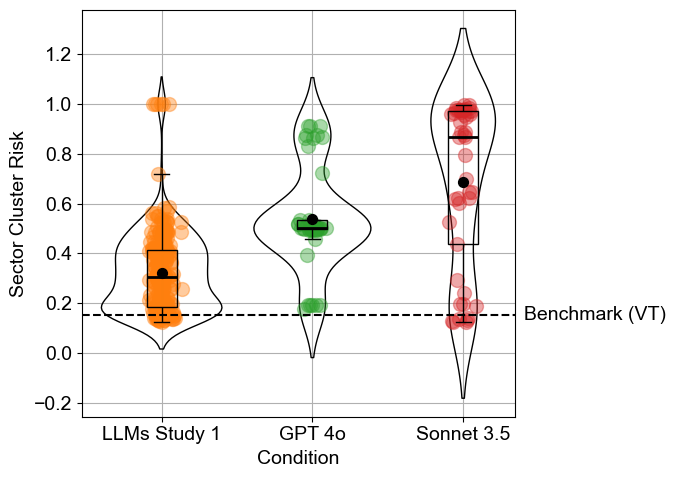

In [37]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'llm',
    'robustness_comb_sectorRisk'
)

## Concentration Map

In [38]:
# Selects only investment assets and assets with known country and sector
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(filtered_df.shape)
    return filtered_df

# Calculates the means, stds, and sample sizes
def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

# Calculates the t-test between a sample and a fixed value across groups
def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)} and dif: {round(group_values.mean()-benchmark_val, 4)}')

filtered_df = prepare_overview_data(df_resolved_full)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)


(2488338, 11)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/3366168126.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()


             sum_sq      df           F  PR(>F)
label     54.172205    13.0  333.711011     0.0
Residual  62.585494  5012.0         NaN     NaN
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
           Academic & Educational Services                            Basic Materials   0.0099 0.9961 -0.0181  0.0379  False
           Academic & Educational Services                     Communication Services   0.0085 0.9992 -0.0195  0.0365  False
           Academic & Educational Services                          Consumer Cyclical   0.2069    0.0  0.1789  0.2348   True
           Academic & Educational Services                     Consumer Non-Cyclicals    0.034 0.0037   0.

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/3366168126.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/3366168126.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  geo_ov = filtered_df.group

              sum_sq     df             F  PR(>F)
label     134.485402    1.0  15002.924527     0.0
Residual    6.140303  685.0           NaN     NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper reject
------------------------------------------------
Non-US     US   0.8858   0.0 0.8716   0.9   True
------------------------------------------------
means:
country
Non-US    0.0597
US        0.9455
Name: weight, dtype: float64
stds:
country
Non-US    0.0961
US        0.0934
Name: weight, dtype: float64
country
Non-US    328
US        359
Name: weight, dtype: int64
(9485, 16)
group: Non-US with mean 0.0597 and std 0.0961 got t: -66.09 p_value: 0.0 dfs: 327 benchmark: 0.4104 and dif: -0.3507
group: US with mean 0.9455 and std 0.0934 got t: 72.22 p_value: 0.0 dfs: 358 benchmark: 0.5896 and dif: 0.3558


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/3366168126.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/460013118.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()


(9485, 16)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/460013118.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()


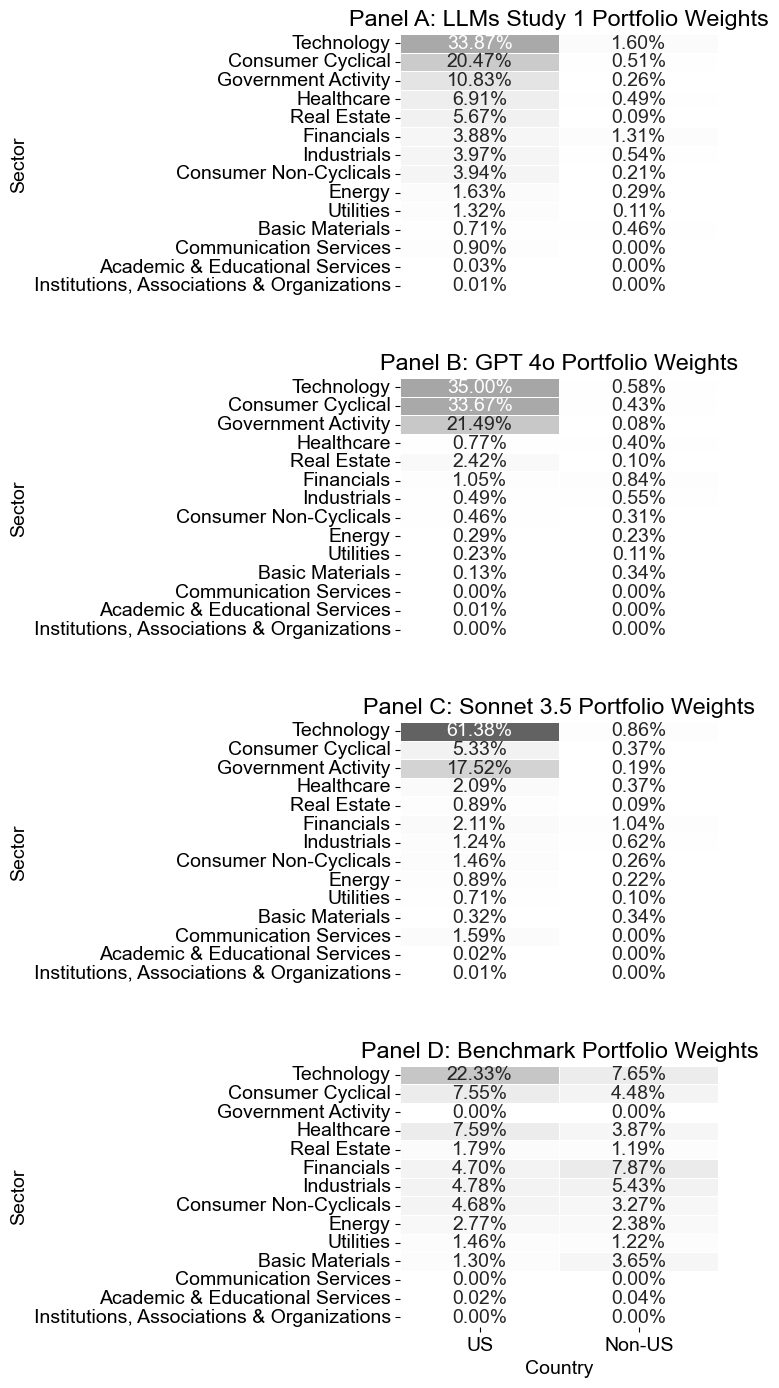

In [39]:
# Creates a data frame which contains all combinations of countries and sectors within each portfolio
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

# Prints a Seaborn heatmap
def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

# Prints a sector, country concentration map in vertical orientation
def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    y_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels("Country", y_label)
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLMs'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['llm'] 


combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'robustness_concentration_map_details', False, 4, 14)

## Active investment allocation risk

In [40]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]

ter_data_study2b = pd.read_csv('../study2b/data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study2b = ter_data_study2b.iloc[1:].reset_index()
ter_data_study2b.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study2a = pd.read_csv('../study2a/data/refinitiv/ter_study2a.csv', index_col=0)
ter_data_study2a = ter_data_study2a.iloc[1:].reset_index()
ter_data_study2a.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study3 = pd.read_csv('../study3/data/refinitiv/ter_study3.csv', index_col=0)
ter_data_study3 = ter_data_study3.iloc[1:].reset_index()
ter_data_study3.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_robustness = pd.read_csv('./data/refinitiv/robustness_ter.csv', index_col=0)
ter_data_robustness = ter_data_robustness.iloc[1:].reset_index()
ter_data_robustness.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study2b, ter_data_study2a, ter_data_study3, ter_data_robustness], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [41]:
df_tmp['asset_type'].replace('Saving', 'SAVING', inplace=True)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/2079764132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_tmp['asset_type'].replace('Saving', 'SAVING', inplace=True)


In [42]:
management_dict = {}

In [43]:
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in management_dict:
            return management_dict[ticker]
        else:
            if ticker in ter_data['fund'].unique():
                approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
                management_dict[ticker] = approach
                return approach
            else:
                management_dict[ticker] = 'UNKNOWN'
                return 'UNKNOWN'

def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_df = df_tmp[~df_tmp['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_df = investment_df.copy()
investment_df['management_approach'] = investment_df.progress_apply(set_management_approach, axis=1)
management_data = get_management_data(investment_df, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive'])
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100

100%|██████████████████████████████████████| 470/470 [00:00<00:00, 37227.08it/s]
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/2174045454.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4235887395.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [44]:
df_study1['asset_type'].replace('Saving', 'SAVING', inplace=True)

investment_df_study1 = df_study1[~df_study1['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_df_study1 = investment_df_study1.copy()
investment_df_study1['management_approach'] = investment_df_study1.progress_apply(set_management_approach, axis=1)
management_data_study1 = get_management_data(investment_df_study1, group_cols)
management_data_study1 = prepare_dataframe_study1(management_data_study1, 'management_weight', 'management_approach', ['Active', 'Passive'])
management_data_study1 = management_data_study1[management_data_study1['management_approach'] == 'Active']
management_data_study1['management_weight'] = management_data_study1['management_weight'] *100
management_data_study1 = management_data_study1[sorted(management_data_study1.columns)]

management_data['llm'] = management_data['ai']
management_data = management_data[sorted(management_data.columns)]

management_data_comb = pd.concat([management_data_study1, management_data], ignore_index=True)
management_data_comb['llm'] = pd.Categorical(management_data_comb['llm'], categories=llm_order, ordered=True)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/2874518090.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_study1['asset_type'].replace('Saving', 'SAVING', inplace=True)
100%|████████████████████████████████████| 1286/1286 [00:00<00:00, 47171.94it/s]
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/2174045454.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclu

                 sum_sq     df         F    PR(>F)
label       8334.219583    2.0  3.345389  0.036355
Residual  444689.199174  357.0       NaN       NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
      GPT 4o LLMs Study 1  -0.7198 0.9912 -14.0944 12.6548  False
      GPT 4o   Sonnet 3.5 -15.1481 0.1052 -32.6596  2.3633  False
LLMs Study 1   Sonnet 3.5 -14.4284 0.0309  -27.803 -1.0537   True
-----------------------------------------------------------------
group: ('LLMs Study 1',) got t: 26.66 p_value: 0.0 dfs: 269 benchmark: 0 d: 55.5
group: ('GPT 4o',) got t: 8.91 p_value: 0.0 dfs: 44 benchmark: 0 d: 56.22
group: ('Sonnet 3.5',) got t: 8.08 p_value: 0.0 dfs: 44 benchmark: 0 d: 41.07
means:
llm
LLMs Study 1    55.50
GPT 4o          56.22
Sonnet 3.5      41.07
Name: management_weight, dtype: float64
stds:
llm
LLMs Study 1    34.20
GPT

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_data in raw.groupby(groups):
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = raw.groupby(groups)[column]


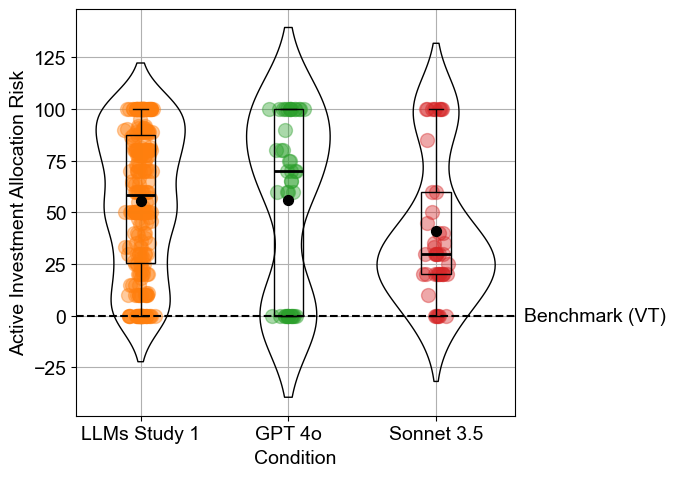

In [45]:
show_benchmark_violinplot(
    management_data_comb, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'llm',
    'robustness_comb_activeRisk'
)

## Total Expense Risk

In [46]:
fund_identifiers = ter_data['fund'].unique()

# Assigns the TER of an asset depending on the ticker symbol
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

# Calculates the weight of an asset within a portfolio
def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

In [47]:
filtered_df = df_full[df_full['asset_type'].isin(['ETF', 'MUTUALFUND'])]
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()
grouped_ter['llm'] = pd.Categorical(grouped_ter['llm'], categories=llm_order, ordered=True)
grouped_ter = grouped_ter.sort_values(by='llm').reset_index(drop=True)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/2456820666.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()


             sum_sq     df         F    PR(>F)
label      0.999976    2.0  8.458161  0.000262
Residual  19.448211  329.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
      GPT 4o LLMs Study 1   -0.142 0.0011 -0.2349 -0.0491   True
      GPT 4o   Sonnet 3.5   -0.042 0.6915 -0.1627  0.0787  False
LLMs Study 1   Sonnet 3.5      0.1 0.0315  0.0071  0.1929   True
----------------------------------------------------------------
group: ('LLMs Study 1',) got t: 6.83 p_value: 0.0 dfs: 241 benchmark: 0.07 d: 0.09
group: ('GPT 4o',) got t: 4.88 p_value: 0.0 dfs: 44 benchmark: 0.07 d: 0.23
group: ('Sonnet 3.5',) got t: 4.25 p_value: 0.0001 dfs: 44 benchmark: 0.07 d: 0.19
means:
llm
LLMs Study 1    0.16
GPT 4o          0.30
Sonnet 3.5      0.26
Name: ter_weight, dtype: float64
stds:
llm
LLMs Study 1    0.21
GPT 4o          0.32
Son

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_data in raw.groupby(groups):
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = raw.groupby(groups)[column]


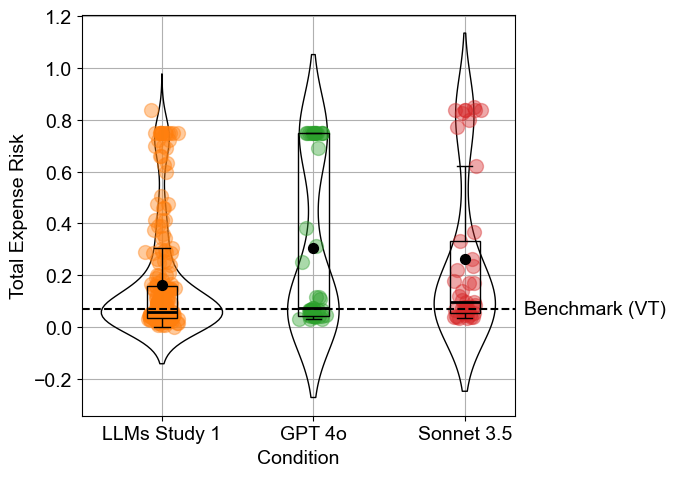

In [48]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'llm',
    'robustness_comb_terRisk'
)

## Trend Chasing Risk

Here we are more interested in macro-level trends (trends that persist over a longer period of time). Therefore, we test this against the
trends when the original dataset was sourced (additionally we do not have data over the period of 3 months following the new data collection).

In [49]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_equities = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [50]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'
with open(json_file_path, 'r') as json_file:
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

1. Symbol: TSLA, Total Volume: 8627649000
2. Symbol: PLTR, Total Volume: 4490639300
3. Symbol: AMD, Total Volume: 4201460900
4. Symbol: AMZN, Total Volume: 3899624000
5. Symbol: F, Total Volume: 3708650700
6. Symbol: AAPL, Total Volume: 3541966300
7. Symbol: NIO, Total Volume: 3235177200
8. Symbol: SOFI, Total Volume: 3204363300
9. Symbol: BAC, Total Volume: 3044131000
10. Symbol: NKLA, Total Volume: 3010655200
11. Symbol: NVDA, Total Volume: 2965437300
12. Symbol: INTC, Total Volume: 2762170900
13. Symbol: CCL, Total Volume: 2498772900
14. Symbol: T, Total Volume: 2442695800
15. Symbol: GOOGL, Total Volume: 2081408400
16. Symbol: LCID, Total Volume: 1905241200
17. Symbol: AI, Total Volume: 1890107300
18. Symbol: NU, Total Volume: 1711794600
19. Symbol: MSFT, Total Volume: 1699893000
20. Symbol: PACW, Total Volume: 1662858500


In [51]:
# Determines the assets with the highest money allocation in GenAI advice
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['ai'] == co]['amount_to_invest']
        top_total = cond[cond['ai'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['ai'] == co]
        top_cond = top_cond.copy()
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

# Prints the top asset data
def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict
    

ais = df_full['ai'].unique()
ageRisk_cond = df_full.groupby(['ai'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = df_full[df_full['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['ai'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['ai','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(ais, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(ais, top_data)

ChatGPT top: % of equities: 0.9999999999999999 and % of total 0.3935037273695421
ChatGPT top 3: % of equities: 0.6427604871447903 and % of total 0.25292864749733757
         ai ticker_symbol  amount_to_invest  pct_of_equities  pct_of_total
0   ChatGPT          AAPL             95500         0.258457      0.101704
23  ChatGPT          TSLA             92000         0.248985      0.097977
2   ChatGPT          AMZN             50000         0.135318      0.053248

Copilot top: % of equities: 0.9999999999999999 and % of total 0.31067961165048535
Copilot top 3: % of equities: 0.5528169014084507 and % of total 0.17174894024340215
         ai ticker_symbol  amount_to_invest  pct_of_equities  pct_of_total
41  Copilot          TSLA             68000         0.239437      0.074388
38  Copilot          NVDA             48000         0.169014      0.052509
28  Copilot          AAPL             41000         0.144366      0.044852

Gemini top: % of equities: 1.0 and % of total 0.3803680981595092
Ge

In [52]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

,fund,code,equity,symbol,#shares,weight,country,type,sector,amount,cond,llm,ai,age,risk_taking,iteration
93854,VT,LP40120747,APPLE INC ORD,AAPL,8132495.0,0.038911,UNITED STATES,Ordinary Shares,Technology,389.11,VT,VT,VT,1,low,0
93855,VT,NaN,MICROSOFT CORP ORD,MSFT,4055679.0,0.033854,UNITED STATES,Ordinary Shares,Technology,338.54,VT,VT,VT,1,low,0
93856,VT,NaN,AMAZON.COM INC ORD,AMZN,4909845.0,0.017257,UNITED STATES,Ordinary Shares,Consumer Cyclical,172.57,VT,VT,VT,1,low,0


In [53]:
# Calculates the share of the top 3 assets by volume in GenAI advice
def calcTopMeans(df, top_dict):
    top_df = None

    for ai, top_assets in top_dict.items():
        filtered_df = df[(df['ai'] == ai) & (df['ticker'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])

    top_df = prepare_dataframe(top_df, 'weight')
    print(top_df.head(20))
    result = top_df.groupby(['ai', 'age', 'risk_taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('ai')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(df_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

        ai  age risk_taking  iteration ticker asset_type      amount  \
0   GPT 4o   15      averse          0   AAPL        ETF     1.95873   
1   GPT 4o   15      averse          0   TSLA        ETF     0.48069   
2   GPT 4o   15      averse          0   PLTR        ETF     0.02268   
3   GPT 4o   15      averse          1   AAPL        ETF     1.95873   
4   GPT 4o   15      averse          1   TSLA        ETF     0.48069   
5   GPT 4o   15      averse          1   PLTR        ETF     0.02268   
6   GPT 4o   15      averse          2   AAPL        ETF     1.95873   
7   GPT 4o   15      averse          2   TSLA        ETF     0.48069   
8   GPT 4o   15      averse          2   PLTR        ETF     0.02268   
9   GPT 4o   15      averse          3   AAPL        ETF     1.95873   
10  GPT 4o   15      averse          3   TSLA        ETF     0.48069   
11  GPT 4o   15      averse          3   PLTR        ETF     0.02268   
12  GPT 4o   15      averse          4   AAPL        ETF     1.9

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4235887395.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result_df[col_name].fillna(0, inplace=True)


In [54]:
def calcTopMeans(df, top_dict):
    top_df = None

    for ai, top_assets in top_dict.items():
        filtered_df = df[(df['ai'] == ai) & (df['ticker'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])

    top_df = prepare_dataframe_study1(top_df, 'weight')
    print(top_df.head(20))
    result = top_df.groupby(['ai', 'age', 'risk_taking', 'iteration'])['weight'].sum().reset_index()
    return result

trends_data_s1 = calcTopMeans(df_study1_resolved, top_dict)
trends_data_s1['weight'] = trends_data_s1['weight'] *100

         ai  age risk_taking  iteration ticker asset_type  amount    weight  \
0   ChatGPT   15      averse          0    NaN        NaN     NaN  0.000000   
1   ChatGPT   15      averse          1   AAPL     EQUITY  2000.0  0.200000   
2   ChatGPT   15      averse          2    NaN        NaN     NaN  0.000000   
3   ChatGPT   15      averse          3    NaN        NaN     NaN  0.000000   
4   ChatGPT   15      averse          4   AMZN     EQUITY  1500.0  0.157895   
5   ChatGPT   15      averse          5    NaN        NaN     NaN  0.000000   
6   ChatGPT   15      averse          6    NaN        NaN     NaN  0.000000   
7   ChatGPT   15      averse          7    NaN        NaN     NaN  0.000000   
8   ChatGPT   15      averse          8    NaN        NaN     NaN  0.000000   
9   ChatGPT   15      averse          9    NaN        NaN     NaN  0.000000   
10  ChatGPT   15     neutral          0   AAPL     EQUITY  3000.0  0.260870   
11  ChatGPT   15     neutral          0   AMZN     E

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/3804690741.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result_df[col_name].fillna(0, inplace=True)


In [55]:
trends_data_s1['llm'] = 'LLMs Study 1'
trends_data['llm'] = trends_data['ai']
trends_data_comb = pd.concat([trends_data_s1, trends_data], ignore_index=True)
trends_data_comb['llm'] = pd.Categorical(trends_data_comb['llm'], categories=llm_order, ordered=True)

                 sum_sq     df         F    PR(>F)
label       2519.028438    2.0  2.352525  0.096602
Residual  191133.618139  357.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
      GPT 4o LLMs Study 1  -3.3172 0.6467 -12.0856 5.4512  False
      GPT 4o   Sonnet 3.5 -10.1369 0.0958 -21.6174 1.3437  False
LLMs Study 1   Sonnet 3.5  -6.8197 0.1611 -15.5881 1.9487  False
----------------------------------------------------------------
group: ('LLMs Study 1',) got t: 9.65 p_value: 0.0 dfs: 269 benchmark: 9.0 d: 14.48
group: ('GPT 4o',) got t: 5.75 p_value: 0.0 dfs: 44 benchmark: 9.0 d: 17.8
group: ('Sonnet 3.5',) got t: 3.66 p_value: 0.0007 dfs: 44 benchmark: 9.0 d: 7.66
means:
llm
LLMs Study 1    23.48
GPT 4o          26.80
Sonnet 3.5      16.66
Name: weight, dtype: float64
stds:
llm
LLMs Study 1    24.65
GPT 4o        

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_data in raw.groupby(groups):
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_29831/4156476844.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = raw.groupby(groups)[column]


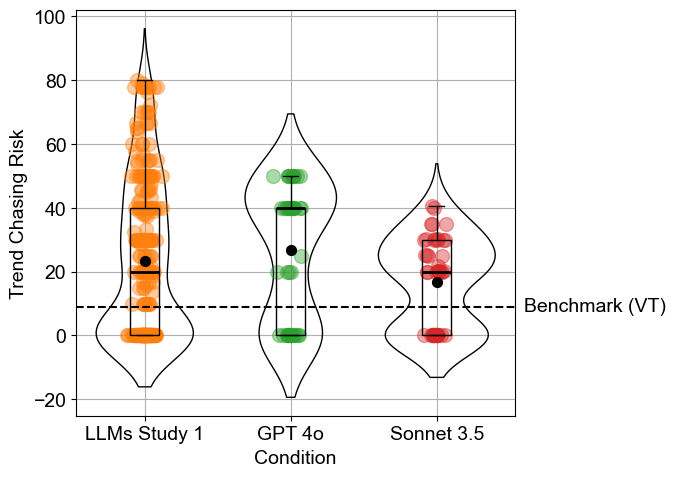

In [56]:
show_benchmark_violinplot(
    trends_data_comb, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'llm',
    'robustness_comb_trendRisk'
)

## MANOVA

In [57]:
geo_us.rename(columns={'weight': 'us_weight'}, inplace=True)
trends_data_comb.rename(columns={'weight': 'trends_weight'}, inplace=True)
print(geo_us.shape)
print(sec.shape)
print(management_data_comb.shape)
print(grouped_ter.shape)
print(trends_data_comb.shape)

(359, 9)
(359, 7)
(360, 10)
(332, 6)
(360, 6)


In [58]:
df_metrics = geo_us.merge(
    sec[['llm','ai', 'age', 'risk_taking', 'iteration', 'concentration']], 
    on=['llm', 'ai', 'age', 'risk_taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    management_data_comb[['llm', 'ai', 'age', 'risk_taking', 'iteration', 'management_weight']], 
    on=['llm', 'ai', 'age', 'risk_taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    grouped_ter[['llm', 'ai', 'age', 'risk_taking', 'iteration', 'ter_weight']], 
    on=['llm', 'ai', 'age', 'risk_taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    trends_data_comb[['llm', 'ai', 'age', 'risk_taking', 'iteration', 'trends_weight']], 
    on=['llm', 'ai', 'age', 'risk_taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.dropna()

In [59]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ llm', data = df_metrics)
print(manova.mv_test())

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ llm + risk_taking + age', data = df_metrics)
print(manova.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0120 5.0000 325.0000 5331.2115 0.0000
         Pillai's trace  0.9880 5.0000 325.0000 5331.2115 0.0000
 Hotelling-Lawley trace 82.0186 5.0000 325.0000 5331.2115 0.0000
    Roy's greatest root 82.0186 5.0000 325.0000 5331.2115 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
            llm           Value   Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
            Wilks' lambda 0.5289 10.0000 650.0000 24.3780 0.0000
           Pillai's trace 0.4821 10.0000 652.

## Plotting

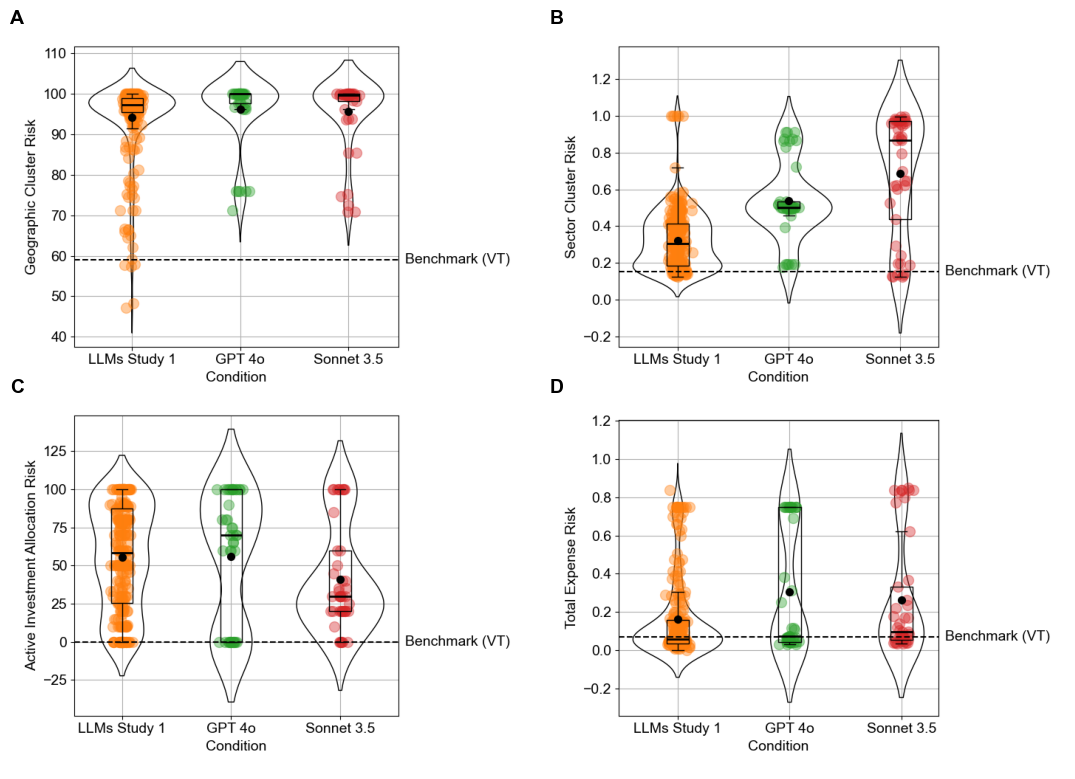

In [60]:
from matplotlib.gridspec import GridSpec
from PIL import Image

img1 = Image.open('./figures/robustness_comb_geoRisk.png')
img2 = Image.open('./figures/robustness_comb_sectorRisk.png')
img3 = Image.open('./figures/robustness_comb_activeRisk.png')
img4 = Image.open('./figures/robustness_comb_terRisk.png')

fig = plt.figure(figsize=(11, 8))

gs = GridSpec(2, 2, height_ratios=[1, 1])

def add_fig(fig, gs, position, img, lab):
    ax = fig.add_subplot(gs[position])
    ax.set_title(lab, fontweight='bold', loc='left', fontsize=14, fontfamily='Arial')
    ax.imshow(img)
    ax.axis('off')

# Add images to the grid
add_fig(fig, gs, (0, 0), img1, 'A') 
add_fig(fig, gs, (0, 1), img2, 'B')
add_fig(fig, gs, (1, 0), img3, 'C')
add_fig(fig, gs, (1, 1), img4, 'D')

plt.tight_layout()
plt.subplots_adjust(hspace= 0)

plt.savefig('./figures/robustness_panels.png')

plt.show()